# Gibrán Leonardo Chávez González
## Exp: 757366
### Fecha: 06/04/2026

Importación de librerías

In [108]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder

Carga del dataset

In [109]:
df = pd.read_csv('brain_tumor_dataset.csv')

EDA

In [110]:
df.head()

,Patient_ID,Age,Gender,Tumor_Type,Tumor_Size,Location,Histology,Stage,Symptom_1,Symptom_2,Symptom_3,Radiation_Treatment,Surgery_Performed,Chemotherapy,Survival_Rate,Tumor_Growth_Rate,Family_History,MRI_Result,Follow_Up_Required
0,1,73,Male,Malignant,5.375612,Temporal,Astrocytoma,III,Vision Issues,Seizures,Seizures,No,No,No,51.312579,0.111876,No,Positive,Yes
1,2,26,Male,Benign,4.847098,Parietal,Glioblastoma,II,Headache,Headache,Nausea,Yes,Yes,Yes,46.373273,2.165736,Yes,Positive,Yes
2,3,31,Male,Benign,5.588391,Parietal,Meningioma,I,Vision Issues,Headache,Seizures,No,No,No,47.072221,1.884228,No,Negative,No
3,4,29,Male,Malignant,1.436600,Temporal,Medulloblastoma,IV,Vision Issues,Seizures,Headache,Yes,No,Yes,51.853634,1.283342,Yes,Negative,No
4,5,54,Female,Benign,2.417506,Parietal,Glioblastoma,I,Headache,Headache,Seizures,No,No,Yes,54.708987,2.069477,No,Positive,Yes


In [111]:
df.describe()

,Patient_ID,Age,Tumor_Size,Survival_Rate,Tumor_Growth_Rate
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,49.433700,5.236552,70.131699,1.547701
std,5773.647028,17.389296,2.754359,17.270834,0.835995
min,1.000000,20.000000,0.500410,40.002386,0.100017
25%,5000.750000,34.000000,2.836686,55.224439,0.830433
50%,10000.500000,49.000000,5.200675,70.305066,1.541821
75%,15000.250000,65.000000,7.624299,85.043395,2.262484
max,20000.000000,79.000000,9.999420,99.998125,2.999835


Valores unicos

In [112]:
for col in df.columns:
    print(f'{col} -> {df[col].unique()}')
    

Patient_ID -> [    1     2     3 ... 19998 19999 20000]
Age -> [73 26 31 29 54 27 72 61 50 79 58 71 62 37 20 67 65 36 46 55 76 49 41 38
 63 44 56 70 42 64 48 52 78 23 39 33 32 34 30 25 75 43 47 28 60 66 35 57
 22 21 59 69 45 40 51 74 24 53 68 77]
Gender -> ['Male' 'Female']
Tumor_Type -> ['Malignant' 'Benign']
Tumor_Size -> [5.37561155 4.84709779 5.58839071 ... 3.61863429 8.5190863  9.71676844]
Location -> ['Temporal' 'Parietal' 'Frontal' 'Occipital']
Histology -> ['Astrocytoma' 'Glioblastoma' 'Meningioma' 'Medulloblastoma']
Stage -> ['III' 'II' 'I' 'IV']
Symptom_1 -> ['Vision Issues' 'Headache' 'Seizures' 'Nausea']
Symptom_2 -> ['Seizures' 'Headache' 'Vision Issues' 'Nausea']
Symptom_3 -> ['Seizures' 'Nausea' 'Headache' 'Vision Issues']
Radiation_Treatment -> ['No' 'Yes']
Surgery_Performed -> ['No' 'Yes']
Chemotherapy -> ['No' 'Yes']
Survival_Rate -> [51.31257903 46.37327271 47.07222097 ... 89.54380317 83.30678093
 47.43346759]
Tumor_Growth_Rate -> [0.11187562 2.16573562 1.88422778 ..

Distribuciones

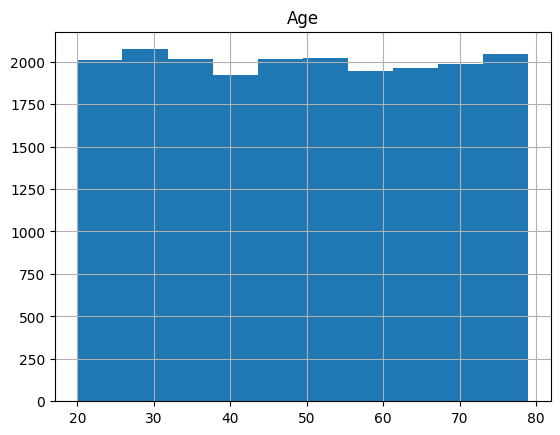

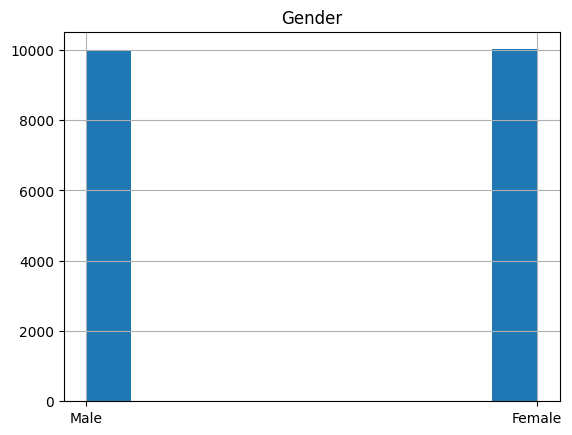

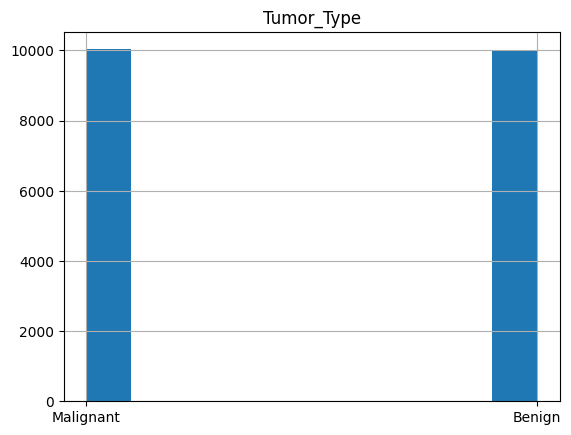

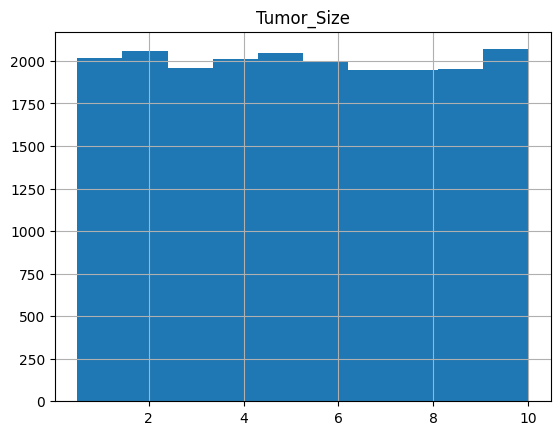

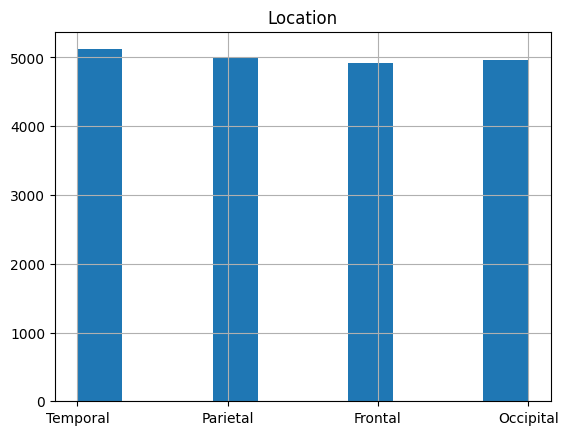

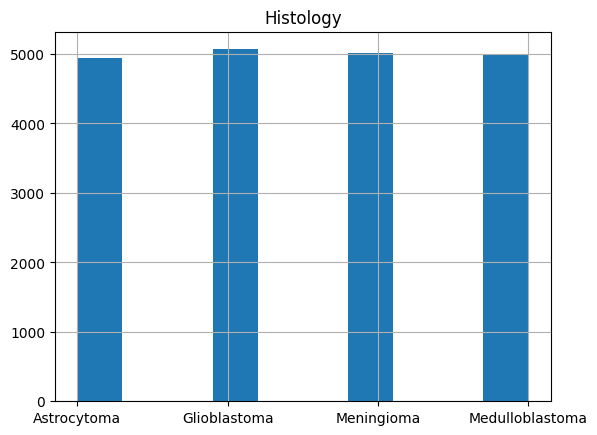

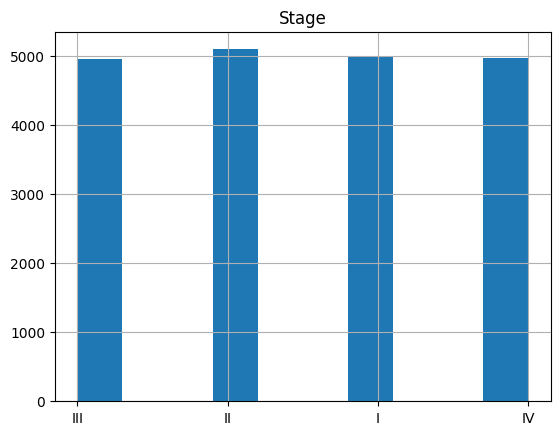

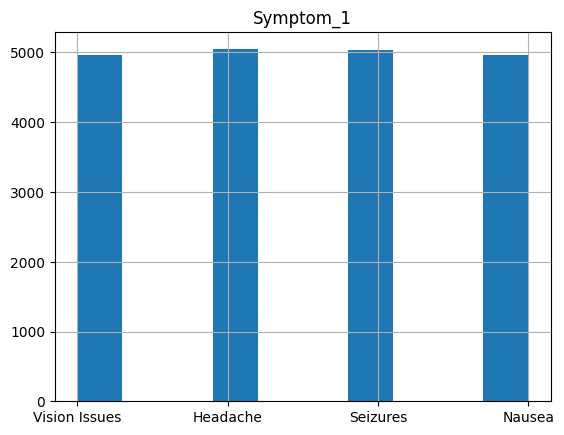

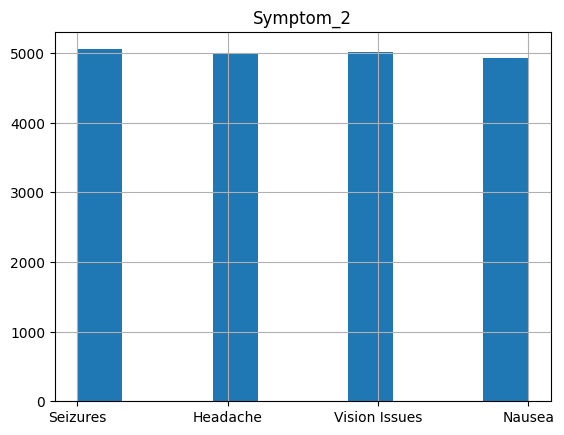

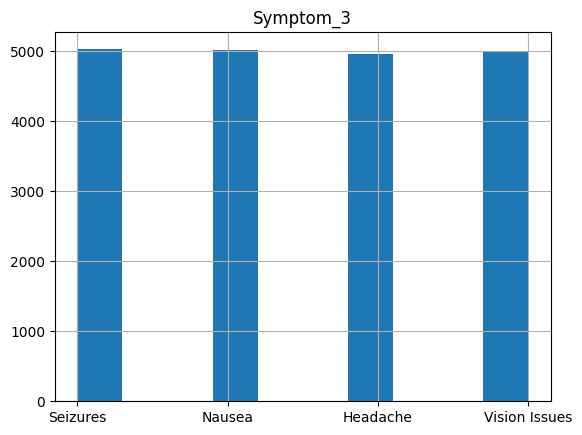

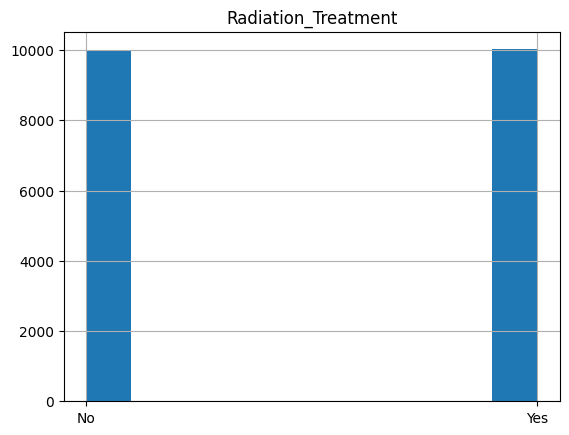

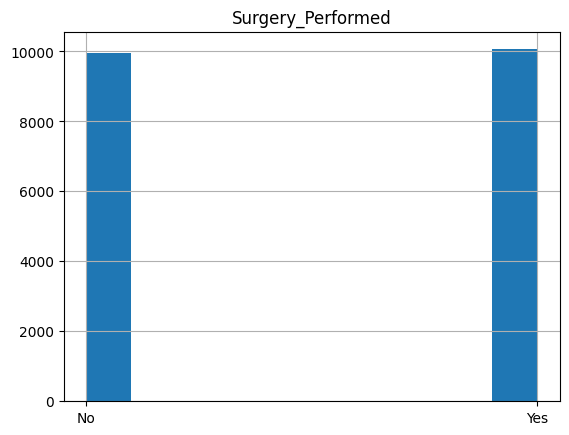

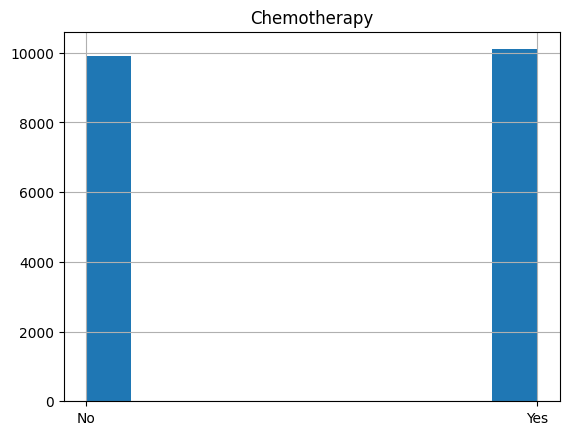

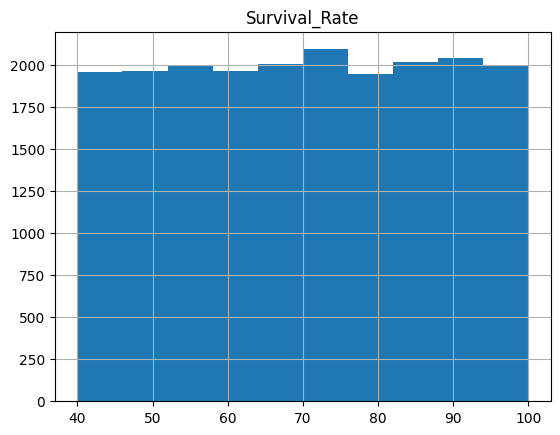

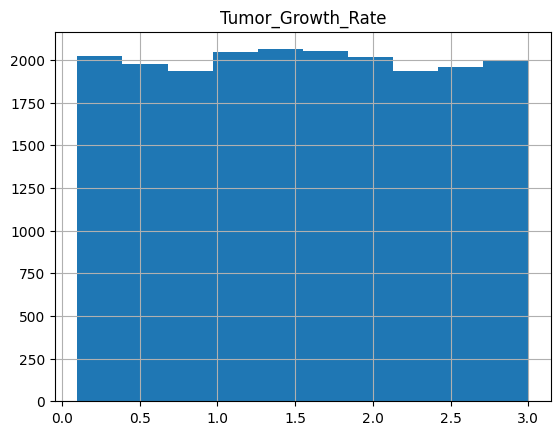

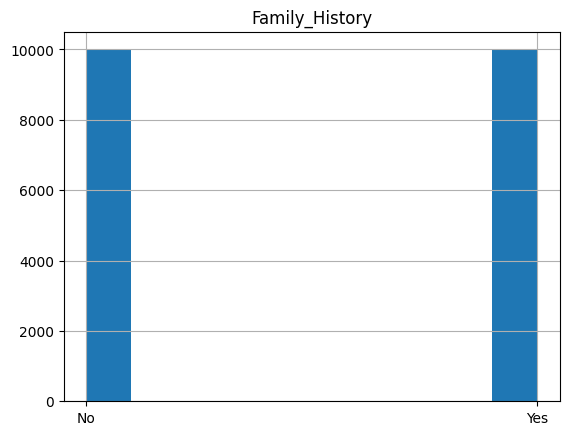

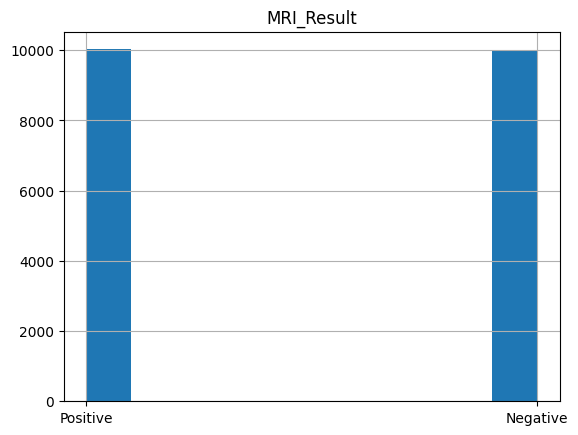

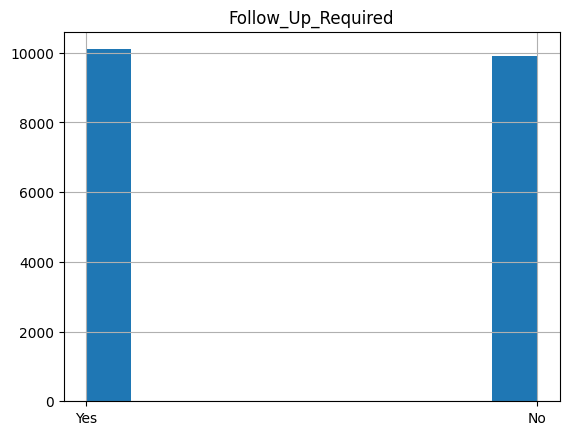

In [113]:
for col in df.columns:
    if col != 'Patient_ID':
        df[col].hist()
        plt.title(col)
        plt.show()

Porcentajes

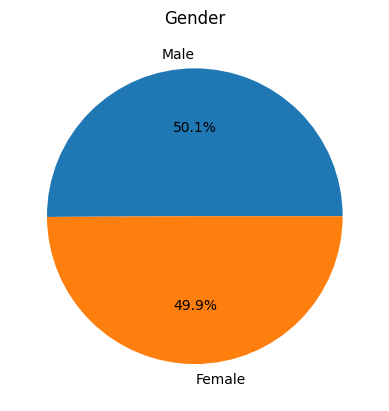

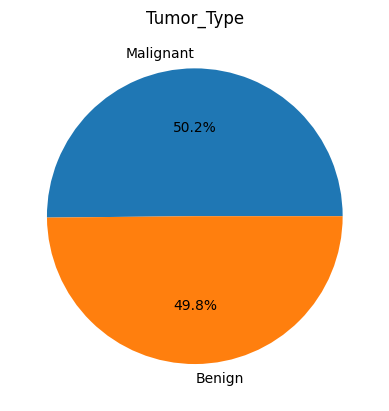

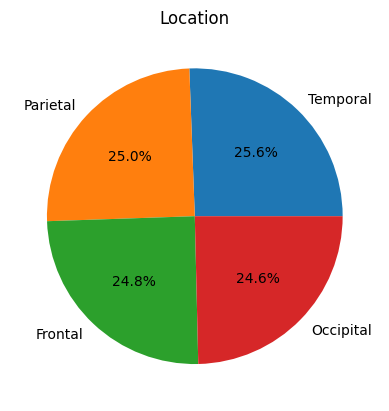

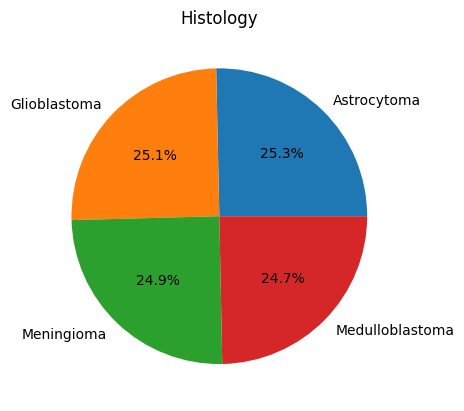

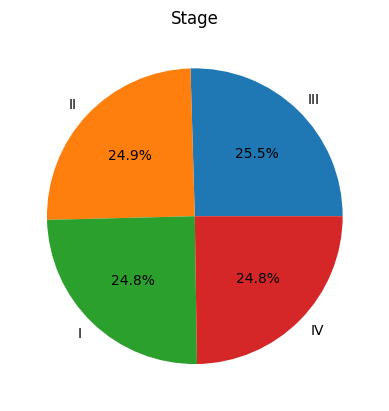

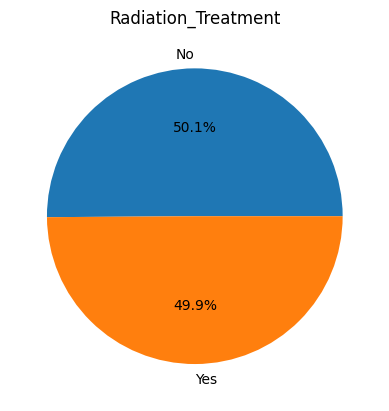

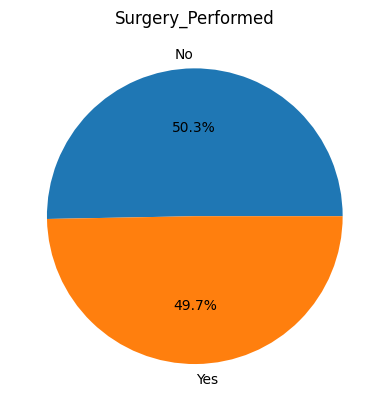

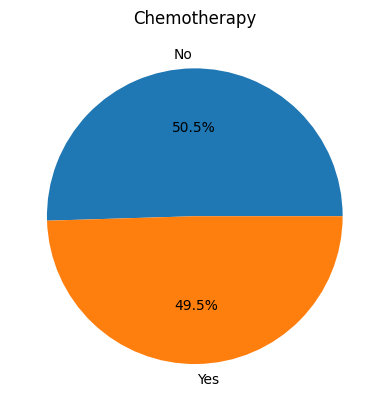

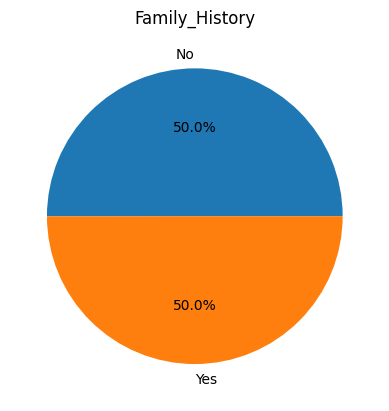

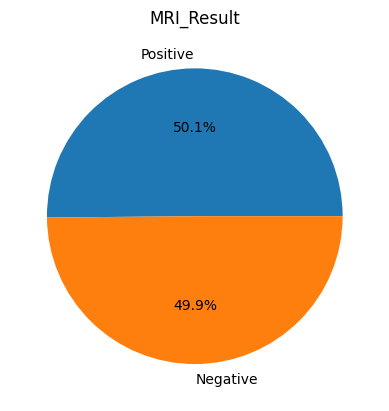

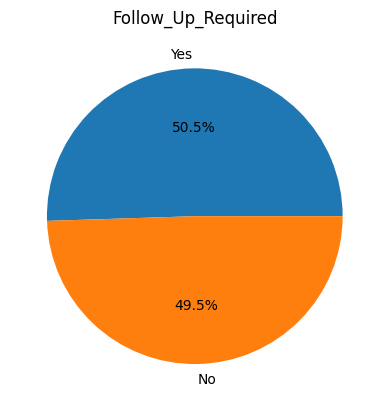

In [114]:
for col in ['Gender', 'Tumor_Type', 'Location',
       'Histology', 'Stage',
       'Radiation_Treatment', 'Surgery_Performed', 'Chemotherapy',
       'Family_History', 'MRI_Result',
       'Follow_Up_Required']:
       plt.pie(df[col].value_counts(), labels=df[col].unique(), autopct='%1.1f%%')
       plt.title(col)
       plt.show()

# Pipeline

In [115]:
for col in df.columns:
    print(f'{col} -> {df[col].unique()}')

Patient_ID -> [    1     2     3 ... 19998 19999 20000]
Age -> [73 26 31 29 54 27 72 61 50 79 58 71 62 37 20 67 65 36 46 55 76 49 41 38
 63 44 56 70 42 64 48 52 78 23 39 33 32 34 30 25 75 43 47 28 60 66 35 57
 22 21 59 69 45 40 51 74 24 53 68 77]
Gender -> ['Male' 'Female']
Tumor_Type -> ['Malignant' 'Benign']
Tumor_Size -> [5.37561155 4.84709779 5.58839071 ... 3.61863429 8.5190863  9.71676844]
Location -> ['Temporal' 'Parietal' 'Frontal' 'Occipital']
Histology -> ['Astrocytoma' 'Glioblastoma' 'Meningioma' 'Medulloblastoma']
Stage -> ['III' 'II' 'I' 'IV']
Symptom_1 -> ['Vision Issues' 'Headache' 'Seizures' 'Nausea']
Symptom_2 -> ['Seizures' 'Headache' 'Vision Issues' 'Nausea']
Symptom_3 -> ['Seizures' 'Nausea' 'Headache' 'Vision Issues']
Radiation_Treatment -> ['No' 'Yes']
Surgery_Performed -> ['No' 'Yes']
Chemotherapy -> ['No' 'Yes']
Survival_Rate -> [51.31257903 46.37327271 47.07222097 ... 89.54380317 83.30678093
 47.43346759]
Tumor_Growth_Rate -> [0.11187562 2.16573562 1.88422778 ..

Definición del tipo de datos

In [116]:
target = ['Tumor_Type']
num_cols = ['Age', 'Tumor_Size', 'Tumor_Growth_Rate']
cat_cols = ['Gender', 'Location', 'Histology', 'Radiation_Treatment', 'Surgery_Performed', 'Chemotherapy', 'Family_History', 'MRI_Result', 'Follow_Up_Required']
cat_ord = ['Stage']

X, y

In [117]:
X = df[num_cols + cat_cols + cat_ord]
y = df[target].replace({'Malignant': 1, 'Benign': 0})

C:\Users\gibra\AppData\Local\Temp\ipykernel_23232\2404827368.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = df[target].replace({'Malignant': 1, 'Benign': 0})


In [118]:
X.shape

(20000, 13)

In [119]:
y.shape

(20000, 1)

Escaladores

In [120]:
num_transformer = StandardScaler()
cat_transformer = OneHotEncoder()
categories = ['I', 'II', 'III', 'IV']; cat_num_transformer = OrdinalEncoder(categories=[categories])

Modelo

In [121]:
model = SVC(kernel='linear', random_state=42, C=1)

Ingeniería de características

In [122]:
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols),
    ('cat_ord', cat_num_transformer, cat_ord),
   # ('remainder', 'passthrough')
])

Pipeline final

In [123]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('model', model)]
)

In [124]:
pipeline.fit(X, y)

C:\Users\gibra\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Cross validation

In [125]:
cross_val = cross_val_score(pipeline, X, y, scoring='f1', cv=5) 

C:\Users\gibra\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\gibra\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\gibra\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the sha

In [126]:
cross_val

array([0.49791922, 0.5005015 , 0.50398406, 0.50855867, 0.50025088])

In [127]:
cross_val.mean()

np.float64(0.5022428666566437)

Optimización Bayesiana